In [2]:
%%capture
pip install feature-engine

In [3]:
%%capture
pip install shap

In [4]:
%%capture
pip install lightgbm

In [44]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures
import lightgbm as lgbm
import shap
import optuna
from sklearn.linear_model import LogisticRegression

In [2]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# preparing the data for modeling

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

In [4]:
# drop the fnlwgt variable as it is not useful for modeling
adult.drop(columns=["fnlwgt"], inplace=True)

In [5]:
# gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

In [6]:
# replace ? with NaN
adult.replace("?", np.nan, inplace=True)

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,0,0,0,38,United-States,0
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,1,0,0,40,United-States,1
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,0,0,0,40,United-States,0
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,1,0,0,20,United-States,0


In [7]:
adult.dtypes

age                int64
workclass            str
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender             int64
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income             int64
dtype: object

In [8]:
# impute missing values as average in numerical and "unknown" in categorical
cat_cols = adult.select_dtypes(include=["object", "string"]).columns
num_cols = adult.select_dtypes(include=["number"]).columns

adult[cat_cols] = adult[cat_cols].fillna("unknown")
adult[num_cols] = adult[num_cols].fillna(adult[num_cols].median())

print(adult.isnull().sum().sum())

0


In [9]:
adult.head(20)

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,1,0,0,30,United-States,0
6,29,unknown,HS-grad,9,Never-married,unknown,Unmarried,Black,1,0,0,40,United-States,0
7,63,Self-emp-not-inc,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,1,3103,0,32,United-States,1
8,24,Private,Some-college,10,Never-married,Other-service,Unmarried,White,0,0,0,40,United-States,0
9,55,Private,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,1,0,0,10,United-States,0


In [10]:
# Feature Preprocessing with Feature-engine

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.model_selection import train_test_split

# copy data
df_fe = adult.copy()

# split features/target
X = df_fe.drop("income", axis=1)
y = df_fe["income"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=321, stratify=y
)

# identify variable types
cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(
    tol=0.01,
    variables=cat_cols
)

X_train_fe = rare_encoder.fit_transform(X_train_fe)
X_test_fe = rare_encoder.transform(X_test_fe)

# frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")

X_train_fe = freq_encoder.fit_transform(X_train_fe)
X_test_fe = freq_encoder.transform(X_test_fe)

# exclude problematic variables from discretization
disc_vars = [col for col in num_cols if col not in ["gender", "capital-gain", "capital-loss"]]

# discretize remaining numeric variables
disc = EqualFrequencyDiscretiser(
    q=5,
    variables=disc_vars
)

X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe = disc.transform(X_test_fe)

# drop constant features if any were created
const_drop = DropConstantFeatures()

X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe = const_drop.transform(X_test_fe)

print("Original shape:", X.shape)
print("Transformed train shape:", X_train_fe.shape)

X_train_fe.head(20)

C:\Users\donya\AppData\Local\Temp\ipykernel_19544\3885755293.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
c:\Users\donya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
c:\Users\donya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\feature_engi

Original shape: (48842, 13)
Transformed train shape: (39073, 13)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
48353,0,0.695391,0.323907,0,0.330330,0.113966,0.258900,0.853556,0,0,0,1,0.897116
8310,2,0.695391,0.041742,2,0.135567,0.113966,0.103755,0.853556,0,0,0,3,0.897116
6063,2,0.695391,0.033450,2,0.330330,0.113966,0.258900,0.031300,0,0,0,1,0.065595
8229,0,0.695391,0.028152,0,0.330330,0.112687,0.103755,0.097254,0,0,0,1,0.897116
20762,0,0.695391,0.163566,2,0.330330,0.127863,0.258900,0.853556,1,0,1741,1,0.897116
22952,2,0.695391,0.041742,2,0.135567,0.029432,0.258900,0.853556,0,0,0,1,0.897116
30731,0,0.695391,0.323907,0,0.330330,0.113966,0.258900,0.853556,0,0,0,1,0.897116
20145,3,0.040591,0.323907,0,0.459499,0.124408,0.405216,0.097254,1,0,0,1,0.897116
2872,2,0.695391,0.019348,0,0.459499,0.124408,0.405216,0.853556,1,0,0,3,0.897116
47213,3,0.063701,0.163566,2,0.459499,0.113966,0.405216,0.853556,1,0,0,2,0.897116


In [11]:
print("Dropped constant features:", const_drop.features_to_drop_)

Dropped constant features: []


In [12]:
rare_encoder.encoder_dict_

{'workclass': ['Private',
  'State-gov',
  'Local-gov',
  'Self-emp-not-inc',
  'unknown',
  'Federal-gov',
  'Self-emp-inc',
  'Without-pay',
  'Never-worked'],
 'education': ['HS-grad',
  'Some-college',
  'Bachelors',
  'Masters',
  'Assoc-voc',
  '11th',
  'Assoc-acdm',
  '10th',
  '7th-8th',
  'Prof-school',
  '9th',
  '12th',
  'Doctorate',
  '5th-6th'],
 'marital-status': ['Never-married',
  'Divorced',
  'Married-civ-spouse',
  'Separated',
  'Widowed',
  'Married-spouse-absent',
  'Married-AF-spouse'],
 'occupation': ['Prof-specialty',
  'Exec-managerial',
  'Craft-repair',
  'Adm-clerical',
  'Sales',
  'Other-service',
  'Machine-op-inspct',
  'unknown',
  'Transport-moving',
  'Handlers-cleaners',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv'],
 'relationship': ['Not-in-family',
  'Unmarried',
  'Husband',
  'Own-child',
  'Wife',
  'Other-relative'],
 'race': ['White',
  'Asian-Pac-Islander',
  'Black',
  'Other',
  'Amer-Indian-Eskimo'],
 'native-country': ['

### Automatic Polynomial Feature Generation

In [13]:
# PolynomialFeatures on selected Feature-engine columns

X_train_poly_input = X_train_fe.copy()
X_test_poly_input = X_test_fe.copy()

poly = PolynomialFeatures(
    degree=3,
    interaction_only=True,
    include_bias=False
)

# fit on training data only
X_train_poly = poly.fit_transform(X_train_poly_input)

# transform test data using the same fitted transformer
X_test_poly = poly.transform(X_test_poly_input)

# feature names
poly_feature_names = poly.get_feature_names_out(X_train_poly_input.columns)

# convert back to DataFrames
X_train_poly_df = pd.DataFrame(
    X_train_poly,
    columns=poly_feature_names,
    index=X_train_poly_input.index
)

X_test_poly_df = pd.DataFrame(
    X_test_poly,
    columns=poly_feature_names,
    index=X_test_poly_input.index
)

print("Selected FE train shape:", X_train_poly_input.shape)
print("Expanded train shape:", X_train_poly_df.shape)
print("Selected FE test shape:", X_test_poly_input.shape)
print("Expanded test shape:", X_test_poly_df.shape)

X_train_poly_df.head()

Selected FE train shape: (39073, 13)
Expanded train shape: (39073, 377)
Selected FE test shape: (9769, 13)
Expanded test shape: (9769, 377)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,...,gender capital-gain capital-loss,gender capital-gain hours-per-week,gender capital-gain native-country,gender capital-loss hours-per-week,gender capital-loss native-country,gender hours-per-week native-country,capital-gain capital-loss hours-per-week,capital-gain capital-loss native-country,capital-gain hours-per-week native-country,capital-loss hours-per-week native-country
48353,0.0,0.695391,0.323907,0.0,0.330330,0.113966,0.258900,0.853556,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
8310,2.0,0.695391,0.041742,2.0,0.135567,0.113966,0.103755,0.853556,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
6063,2.0,0.695391,0.033450,2.0,0.330330,0.113966,0.258900,0.031300,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
8229,0.0,0.695391,0.028152,0.0,0.330330,0.112687,0.103755,0.097254,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
20762,0.0,0.695391,0.163566,2.0,0.330330,0.127863,0.258900,0.853556,1.0,0.0,...,0.0,0.0,0.0,1741.0,1561.878356,0.897116,0.0,0.0,0.0,1561.878356


In [14]:
# print all column names in the expanded polynomial feature DataFrame
for col in X_train_poly_df.columns:
    print(col)

age
workclass
education
educational-num
marital-status
occupation
relationship
race
gender
capital-gain
capital-loss
hours-per-week
native-country
age workclass
age education
age educational-num
age marital-status
age occupation
age relationship
age race
age gender
age capital-gain
age capital-loss
age hours-per-week
age native-country
workclass education
workclass educational-num
workclass marital-status
workclass occupation
workclass relationship
workclass race
workclass gender
workclass capital-gain
workclass capital-loss
workclass hours-per-week
workclass native-country
education educational-num
education marital-status
education occupation
education relationship
education race
education gender
education capital-gain
education capital-loss
education hours-per-week
education native-country
educational-num marital-status
educational-num occupation
educational-num relationship
educational-num race
educational-num gender
educational-num capital-gain
educational-num capital-loss
educati

### Baseline models with transformed original features

In [ ]:
# baseline extra trees and LG boost CV models using X_train_poly and X_test_poly datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

# baseline extra trees with class imbalance handling and CV with default parameters
et_baseline_fe = ExtraTreesClassifier(class_weight='balanced', random_state=321, n_jobs=-1)
et_cv_scores = cross_val_score(et_baseline_fe, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("Extra Trees CV Balanced Accuracy Scores:", et_cv_scores)
et_baseline_fe.fit(X_train_poly_df, y_train)
et_preds_fe = et_baseline_fe.predict(X_test_poly_df)
print("Extra Trees adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds_fe))
print("Extra Trees Classification Report:\n", classification_report(y_test, et_preds_fe))

# baseline LG boost with class imbalance handling and CV with default parameters

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

lgb_baseline_fe = lgbm.LGBMClassifier(scale_pos_weight=spw, random_state=321, verbose = 0, n_jobs=-1)
lgb_cv_scores = cross_val_score(lgb_baseline_fe, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("\nLG Boost adult_fe CV Balanced Accuracy Scores:", lgb_cv_scores)    
lgb_baseline_fe.fit(X_train_poly_df, y_train)
lgb_preds_fe = lgb_baseline_fe.predict(X_test_poly_df)
print("LG Boost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_fe)) 
print("LG Boost Classification Report:\n", classification_report(y_test, lgb_preds_fe))

Extra Trees CV Balanced Accuracy Scores: [0.78440383 0.78480051 0.79604305 0.78233387 0.78836242]
Extra Trees adult_fe Test Balanced Accuracy: 0.7827051934541436
Extra Trees Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87      7431
           1       0.58      0.73      0.65      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.78      0.76      9769
weighted avg       0.83      0.81      0.82      9769

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines

LG Boost adult_fe CV Balanced Accuracy Scores: [0.83745182 0.84692435 0.83

In [ ]:
# Rank and display feature importances from baseline models using feature data
et_importances = pd.Series(et_baseline_fe.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
lgb_importances = pd.Series(lgb_baseline_fe.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
print("Top 10 Extra Trees Feature Importances:")
print(et_importances.head(10))
print("\nTop 10 LG Boost Feature Importances:")
print(lgb_importances.head(10))


Top 10 Extra Trees Feature Importances:
marital-status occupation relationship    0.014782
marital-status relationship gender        0.013653
occupation relationship                   0.013470
marital-status                            0.013023
relationship                              0.012810
relationship gender                       0.012674
marital-status occupation                 0.012659
marital-status relationship               0.012481
age marital-status                        0.011653
marital-status race                       0.010454
dtype: float64

Top 10 LG Boost Feature Importances:
capital-gain                                147
capital-loss                                136
marital-status capital-loss                  60
occupation                                   60
marital-status capital-gain                  57
relationship capital-gain                    42
marital-status occupation                    39
age education occupation                     36
age education

In [20]:
# Rank and display permutation importances for baseline models

et_perm_importance = permutation_importance(et_baseline_fe, X_test_poly_df, y_test, n_repeats=10, random_state=321)
lgb_perm_importance = permutation_importance(lgb_baseline_fe, X_test_poly_df, y_test, n_repeats=10, random_state=321)

# saving permutation importance results in DataFrames for easier display
et_perm_importance_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': et_perm_importance.importances_mean,
    'importance_std': et_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

lgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': lgb_perm_importance.importances_mean,
    'importance_std': lgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 10 features by permutation importance for both models
print("Top 10 Extra Trees Permutation Importances:")
print(et_perm_importance_df.head(10))
print("\nTop 10 LG Boost Permutation Importances:")
print(lgb_perm_importance_df.head(10))

Top 10 Extra Trees Permutation Importances:
                                feature  importance_mean  importance_std
60          marital-status capital-loss         0.000266        0.000166
82                  gender capital-loss         0.000225        0.000110
364    race capital-loss hours-per-week         0.000184        0.000077
73            relationship capital-loss         0.000184        0.000128
22                     age capital-loss         0.000174        0.000113
52         educational-num capital-loss         0.000164        0.000050
348    relationship gender capital-loss         0.000133        0.000159
370  gender capital-loss hours-per-week         0.000133        0.000113
77                    race capital-gain         0.000113        0.000155
308    marital-status race capital-loss         0.000113        0.000097

Top 10 LG Boost Permutation Importances:
                            feature  importance_mean  importance_std
9                      capital-gain       

## Average feature importance and permutation rankings

In [23]:
# Extratrees averaged rankings
et_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": et_baseline_fe.feature_importances_
})

#rank feature importance and permutation importance results
et_feat_df["rank_feat"] = et_feat_df["feat_importance"].rank(ascending=False)
et_perm_importance_df["rank_perm"] = et_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
et_combined = (
    et_feat_df
    .merge(et_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
et_combined["rank_avg"] = (et_combined["rank_feat"] + et_combined["rank_perm"]) / 2

#sort and display top 50 features
et_combined = et_combined.sort_values("rank_avg")
et_top_features = et_combined.head(20)
et_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
66,occupation capital-gain,0.002883,113.0,-6.141877e-05,76.0,94.50
77,race capital-gain,0.001855,183.0,1.126011e-04,9.0,96.00
265,educational-num occupation relationship,0.006711,31.0,-7.472617e-04,164.0,97.50
59,marital-status capital-gain,0.002512,127.0,-5.118231e-05,70.5,98.75
316,marital-status capital-gain hours-per-week,0.002016,169.0,1.110223e-17,32.5,100.75
143,age race capital-gain,0.002203,152.0,-2.047292e-05,55.0,103.50
264,educational-num marital-status native-country,0.005596,45.0,-7.882076e-04,169.5,107.25
257,educational-num marital-status occupation,0.008652,21.0,-1.105538e-03,199.0,110.00
207,workclass capital-gain hours-per-week,0.001677,202.0,1.023646e-05,28.5,115.25
9,capital-gain,0.002942,108.0,-2.559116e-04,127.5,117.75


In [24]:
# LG Boost averaged rankings
lgb_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": lgb_baseline_fe.feature_importances_
})

#rank feature importance and permutation importance results
lgb_feat_df["rank_feat"] = lgb_feat_df["feat_importance"].rank(ascending=False)
lgb_perm_importance_df["rank_perm"] = lgb_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
lgb_combined = (
    lgb_feat_df
    .merge(lgb_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
lgb_combined["rank_avg"] = (lgb_combined["rank_feat"] + lgb_combined["rank_perm"]) / 2

#sort and display top 50 features
lgb_combined = lgb_combined.sort_values("rank_avg")
lgb_top_features = lgb_combined.head(50)
lgb_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
9,capital-gain,147,1.0,0.022868,1.0,1.00
60,marital-status capital-loss,60,3.5,0.003347,4.0,3.75
59,marital-status capital-gain,57,5.0,0.004606,3.0,4.00
10,capital-loss,136,2.0,0.001945,7.0,4.50
5,occupation,60,3.5,0.001535,8.0,5.75
72,relationship capital-gain,42,6.0,0.002150,6.0,6.00
55,marital-status occupation,39,7.0,0.001361,10.0,8.50
4,marital-status,25,15.5,0.020268,2.0,8.75
94,age workclass occupation,28,12.5,0.001280,13.0,12.75
159,workclass education occupation,27,14.0,0.000798,18.0,16.00


## Create Reduced datasets

Note: My reduced dataset for the Extra Trees model is final. I am going to use SHAP to further reduce my features in the LG Boost data set.

In [25]:
#Extra trees reduced dataset (top 20 features)
X_train_et_20 = X_train_poly_df[et_top_features["feature"]]
X_test_et_20 = X_test_poly_df[et_top_features["feature"]]

#LG Boost reduced dataset (top 50 features)
X_train_lgb_50 = X_train_poly_df[lgb_top_features["feature"]]
X_test_lgb_50 = X_test_poly_df[lgb_top_features["feature"]]

## Modeling on reduced feature sets (final for Extra Trees)

In [26]:
# baseline extra trees with class imbalance handling and CV with default parameters
et_baseline_20 = ExtraTreesClassifier(class_weight='balanced', random_state=321, n_jobs=-1)
et_cv_scores_20 = cross_val_score(et_baseline_20, X_train_et_20, y_train, cv=skf, scoring='balanced_accuracy')
print("Extra Trees CV Balanced Accuracy Scores (Top 20 Features):", et_cv_scores_20)
et_baseline_20.fit(X_train_et_20, y_train)
et_preds_20 = et_baseline_20.predict(X_test_et_20)
print("Extra Trees (20 Features) Test Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds_20))
print("Extra Trees (20 Features) Classification Report:\n", classification_report(y_test, et_preds_20))

# baseline LG boost with class imbalance handling and CV with default parameters
lgb_baseline_50 = lgbm.LGBMClassifier(scale_pos_weight=spw, random_state=321, verbose = 0, n_jobs=-1)
lgb_cv_scores_50 = cross_val_score(lgb_baseline_50, X_train_lgb_50, y_train, cv=skf, scoring='balanced_accuracy')
print("\nLG Boost adult_fe CV Balanced Accuracy Scores (Top 50 Features):", lgb_cv_scores_50)    
lgb_baseline_50.fit(X_train_lgb_50, y_train)
lgb_preds_50 = lgb_baseline_50.predict(X_test_lgb_50)
print("LG Boost (50 Features) Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_50)) 
print("LG Boost (50 Features) Classification Report:\n", classification_report(y_test, lgb_preds_50))

Extra Trees CV Balanced Accuracy Scores (Top 20 Features): [0.77543413 0.77995957 0.78542387 0.77602596 0.77802844]
Extra Trees (20 Features) Test Balanced Accuracy: 0.7795224189144061
Extra Trees (20 Features) Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.73      0.82      7431
           1       0.49      0.83      0.62      2338

    accuracy                           0.75      9769
   macro avg       0.71      0.78      0.72      9769
weighted avg       0.83      0.75      0.77      9769

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines

LG Boost adult_fe CV Balanced Accurac

### SHAP Analysis on reduced feature set (LG Boost only)

c:\Users\donya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


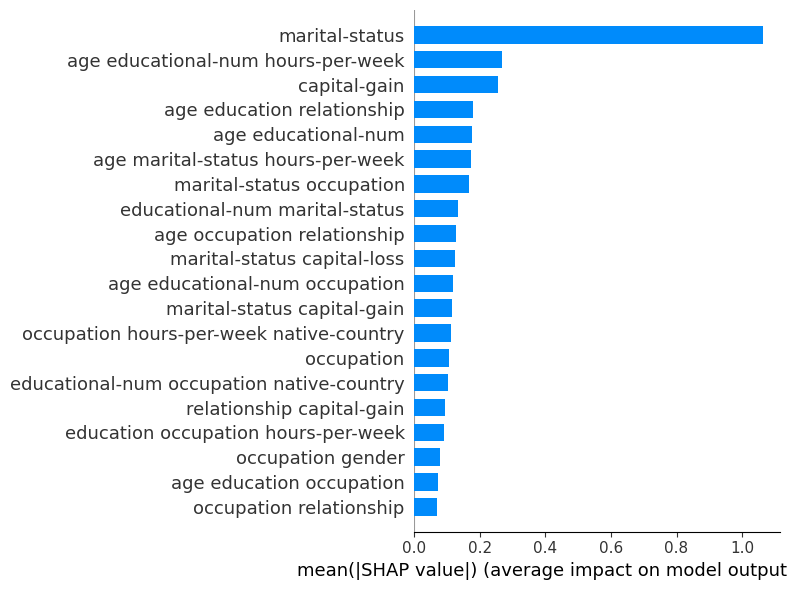

Top 20 features by SHAP:
['marital-status', 'age educational-num hours-per-week', 'capital-gain', 'age education relationship', 'age educational-num', 'age marital-status hours-per-week', 'marital-status occupation', 'educational-num marital-status', 'age occupation relationship', 'marital-status capital-loss', 'age educational-num occupation', 'marital-status capital-gain', 'occupation hours-per-week native-country', 'occupation', 'educational-num occupation native-country', 'relationship capital-gain', 'education occupation hours-per-week', 'occupation gender', 'age education occupation', 'occupation relationship']

X_train_lgb_20 shape: (39073, 20)
X_test_lgb_20 shape:  (9769, 20)


In [32]:
# LightGBM SHAP values on test set
lgb_explainer = shap.TreeExplainer(lgb_baseline_50)
lgb_shap_vals = lgb_explainer.shap_values(X_test_lgb_50)

if isinstance(lgb_shap_vals, list):
    lgb_shap_vals = lgb_shap_vals[1]  # ← overwrite, don't rename

# Global feature importance bar plot
shap.summary_plot(
    lgb_shap_vals,
    X_test_lgb_50,
    plot_type="bar",
    plot_size=(8, 6)
)

# Top 20 features by mean absolute SHAP value
lgb_shap_importance = pd.DataFrame({
    "feature": X_test_lgb_50.columns,
    "shap_mean_abs": np.abs(lgb_shap_vals).mean(axis=0)
}).sort_values("shap_mean_abs", ascending=False)

lgb_top20_features = lgb_shap_importance.head(20)["feature"].tolist()
print("Top 20 features by SHAP:")
print(lgb_top20_features)

# Reduce X_train and X_test to top 20 features
X_train_lgb_20 = X_train_lgb_50[lgb_top20_features]
X_test_lgb_20  = X_test_lgb_50[lgb_top20_features]

print(f"\nX_train_lgb_20 shape: {X_train_lgb_20.shape}")
print(f"X_test_lgb_20 shape:  {X_test_lgb_20.shape}")

## Modeling on reduced feature sets (final for LG Boost)

In [33]:
lgb_baseline_20 = lgbm.LGBMClassifier(scale_pos_weight=spw, random_state=321, verbose = 0, n_jobs=-1)
lgb_cv_scores_20 = cross_val_score(lgb_baseline_20, X_train_lgb_20, y_train, cv=skf, scoring='balanced_accuracy')
print("\nLG Boost adult_fe CV Balanced Accuracy Scores (Top 20 Features):", lgb_cv_scores_20)    
lgb_baseline_20.fit(X_train_lgb_20, y_train)
lgb_preds_20 = lgb_baseline_20.predict(X_test_lgb_20)
print("LG Boost (20 Features) Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_20)) 
print("LG Boost (20 Features) Classification Report:\n", classification_report(y_test, lgb_preds_20))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines

LG Boost adult_fe CV Balanced Accuracy Scores (Top 20 Features): [0.84246052 0.84725582 0.83831805 0.83419121 0.84404666]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
LG Boost (20 Features) Test Balanced Accuracy: 0.8408977649982923
LG Boost (20 Features) Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.81      0.88      7431
           1       0.59      0.87      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.84      0.79      9769
weighted avg

## Model tuning

In [41]:
#Extra trees
def et_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth"        : trial.suggest_int("max_depth", 5, 30),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "max_features"     : trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "class_weight"     : "balanced",
        "random_state"     : 321,
        "n_jobs"           : -1,
    }
    model = ExtraTreesClassifier(**params)
    scores = cross_val_score(model, X_train_et_20, y_train, cv=skf, scoring="balanced_accuracy")
    return scores.mean()

et_study = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=321))
et_study.optimize(et_objective, n_trials=20, show_progress_bar=True)

print(f"Best ET Balanced Accuracy : {et_study.best_value:.4f}")
print(f"Best ET params   : {et_study.best_params}")

best_et = ExtraTreesClassifier(
    **et_study.best_params,
    class_weight="balanced",
    random_state=321,
    n_jobs=-1,
)
best_et.fit(X_train_et_20, y_train)
et_preds_tuned = best_et.predict(X_test_et_20)
print("Extra Trees Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds_tuned))
print("Extra Trees Tuned (20 Features) Classification Report:\n", classification_report(y_test, et_preds_tuned))

[I 2026-04-24 13:57:31,392] A new study created in memory with name: no-name-cc9cd2b3-abf7-445f-838a-9a950a140b12
Best trial: 0. Best value: 0.783072:   5%|▌         | 1/20 [00:10<03:24, 10.77s/it]

[I 2026-04-24 13:57:42,160] Trial 0 finished with value: 0.7830721059648847 and parameters: {'n_estimators': 600, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 6, 'max_features': 0.3}. Best is trial 0 with value: 0.7830721059648847.


Best trial: 1. Best value: 0.792989:  10%|█         | 2/20 [00:13<01:52,  6.26s/it]

[I 2026-04-24 13:57:45,265] Trial 1 finished with value: 0.7929891956705966 and parameters: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 4, 'min_samples_split': 6, 'max_features': 0.3}. Best is trial 1 with value: 0.7929891956705966.


Best trial: 2. Best value: 0.795258:  15%|█▌        | 3/20 [00:17<01:22,  4.88s/it]

...

[I 2026-04-24 14:00:09,869] Trial 17 finished with value: 0.7940606353754239 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 7, 'min_samples_split': 13, 'max_features': 0.5}. Best is trial 10 with value: 0.7953392476649029.


Best trial: 10. Best value: 0.795339:  95%|█████████▌| 19/20 [02:50<00:11, 11.37s/it]

[I 2026-04-24 14:00:22,256] Trial 18 finished with value: 0.7945068061626361 and parameters: {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20, 'max_features': 0.5}. Best is trial 10 with value: 0.7953392476649029.


Best trial: 10. Best value: 0.795339: 100%|██████████| 20/20 [02:58<00:00,  8.92s/it]


[I 2026-04-24 14:00:29,816] Trial 19 finished with value: 0.7909204115665963 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_leaf': 5, 'min_samples_split': 13, 'max_features': 'sqrt'}. Best is trial 10 with value: 0.7953392476649029.
Best ET Balanced Accuracy : 0.7953
Best ET params   : {'n_estimators': 400, 'max_depth': 11, 'min_samples_leaf': 7, 'min_samples_split': 17, 'max_features': 0.5}
Extra Trees Top 20 Test Balanced Accuracy: 0.7988416442390609
Extra Trees Tuned (20 Features) Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.72      0.82      7431
           1       0.50      0.87      0.64      2338

    accuracy                           0.76      9769
   macro avg       0.72      0.80      0.73      9769
weighted avg       0.84      0.76      0.78      9769



In [42]:
# LG Boost
def lgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 15, 127),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight" : spw,
        "random_state"     : 321,
        "verbose"          : -1,
        "n_jobs"           : -1,
    }
    model = lgbm.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_lgb_20, y_train, cv=skf, scoring="balanced_accuracy")
    return scores.mean()

lgb_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=321))
lgb_study.optimize(lgb_objective, n_trials=20, show_progress_bar=True)

print(f"Best LGB Balanced Accuracy : {lgb_study.best_value:.4f}")
print(f"Best LGB params            : {lgb_study.best_params}")

best_lgb = lgbm.LGBMClassifier(
    **lgb_study.best_params,
    scale_pos_weight=spw,
    random_state=321,
    verbose=0,
    n_jobs=-1,
)
best_lgb.fit(X_train_lgb_20, y_train)
lgb_preds_tuned = best_lgb.predict(X_test_lgb_20)
print("LightGBM Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_tuned))
print("LightGBM Tuned (20 Features) Classification Report:\n", classification_report(y_test, lgb_preds_tuned))

[I 2026-04-24 14:01:56,032] A new study created in memory with name: no-name-13b37fdb-4fda-4040-9934-ab6115e1595b
Best trial: 0. Best value: 0.839456:   5%|▌         | 1/20 [00:06<02:10,  6.84s/it]

[I 2026-04-24 14:02:02,875] Trial 0 finished with value: 0.8394558429791411 and parameters: {'n_estimators': 900, 'learning_rate': 0.013034248633067442, 'num_leaves': 125, 'max_depth': 5, 'min_child_samples': 39, 'reg_alpha': 0.12785053365603052, 'reg_lambda': 4.267907644815837}. Best is trial 0 with value: 0.8394558429791411.


Best trial: 1. Best value: 0.840782:  10%|█         | 2/20 [00:16<02:29,  8.30s/it]

[I 2026-04-24 14:02:12,194] Trial 1 finished with value: 0.840782059874568 and parameters: {'n_estimators': 900, 'learning_rate': 0.013547559837878672, 'num_leaves': 73, 'max_depth': 6, 'min_child_samples': 14, 'reg_alpha': 0.02771365251830879, 'reg_lambda': 0.012108788473568655}. Best is trial 1 with value: 0.840782059874568.


Best trial: 1. Best value: 0.840782:  15%|█▌        | 3/20 [00:22<02:02,  7.22s/it]

...

[I 2026-04-24 14:04:15,091] Trial 17 finished with value: 0.8216568453038725 and parameters: {'n_estimators': 700, 'learning_rate': 0.09522254697896565, 'num_leaves': 102, 'max_depth': 9, 'min_child_samples': 13, 'reg_alpha': 0.001379237868562688, 'reg_lambda': 0.24743209032616437}. Best is trial 12 with value: 0.8408635650431953.


Best trial: 12. Best value: 0.840864:  95%|█████████▌| 19/20 [02:25<00:09,  9.60s/it]

[I 2026-04-24 14:04:21,181] Trial 18 finished with value: 0.8400191930298744 and parameters: {'n_estimators': 900, 'learning_rate': 0.03400163472310552, 'num_leaves': 15, 'max_depth': 7, 'min_child_samples': 5, 'reg_alpha': 0.009440770093704007, 'reg_lambda': 0.014497755921992614}. Best is trial 12 with value: 0.8408635650431953.


Best trial: 12. Best value: 0.840864: 100%|██████████| 20/20 [02:32<00:00,  7.61s/it]


[I 2026-04-24 14:04:28,211] Trial 19 finished with value: 0.8388667029454115 and parameters: {'n_estimators': 400, 'learning_rate': 0.024601517265401544, 'num_leaves': 70, 'max_depth': 10, 'min_child_samples': 20, 'reg_alpha': 0.047240827416991975, 'reg_lambda': 0.1282629873124767}. Best is trial 12 with value: 0.8408635650431953.
Best LGB Balanced Accuracy : 0.8409
Best LGB params            : {'n_estimators': 1000, 'learning_rate': 0.021328409807080777, 'num_leaves': 16, 'max_depth': 12, 'min_child_samples': 16, 'reg_alpha': 0.0013239435917324004, 'reg_lambda': 0.36749615429020815}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
LightGBM Top 20 Test Balanced Accuracy: 0.8397517497446425
LightGBM Tuned (20 Features) Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88      7431
           1       0.60      0.86      0.71      2338

    accuracy                           0.83      9769

### MetaLearner using OOF predictions

In [ ]:
# tuned models
et = best_et
lgb_model = best_lgb

# meta model: learns how to best combine ET and LGB's predictions
meta_model = LogisticRegression(class_weight="balanced", random_state=321)

# OOF setup

# store OOF predictions
et_oof  = np.zeros(len(X_train_et_20))
lgb_oof = np.zeros(len(X_train_lgb_20))

# --- Generate OOF predictions ---
for train_idx, val_idx in skf.split(X_train_et_20, y_train):

    # ET fold
    X_tr_et, X_val_et = X_train_et_20.iloc[train_idx], X_train_et_20.iloc[val_idx]
    et.fit(X_tr_et, y_train.iloc[train_idx])
    et_oof[val_idx] = et.predict_proba(X_val_et)[:, 1]

    # LGB fold
    X_tr_lgb, X_val_lgb = X_train_lgb_20.iloc[train_idx], X_train_lgb_20.iloc[val_idx]
    lgb_model.fit(X_tr_lgb, y_train.iloc[train_idx])
    lgb_oof[val_idx] = lgb_model.predict_proba(X_val_lgb)[:, 1]

# --- Train meta model on OOF predictions ---
#meta-learner (Logistic Regression) then trains on this, learning how to best weight ET vs LGB to produce a final prediction
X_meta_train = np.column_stack((et_oof, lgb_oof))
meta_model.fit(X_meta_train, y_train)

# --- Retrain base models on FULL training data ---
et.fit(X_train_et_20, y_train)
lgb_model.fit(X_train_lgb_20, y_train)

# --- Generate test predictions ---
et_test  = et.predict_proba(X_test_et_20)[:, 1]
lgb_test = lgb_model.predict_proba(X_test_lgb_20)[:, 1]

# --- Meta model final predictions ---
X_meta_test = np.column_stack((et_test, lgb_test))
meta_preds  = meta_model.predict(X_meta_test)

# --- Evaluate ---
print("=" * 55)
print("BASE MODEL — ExtraTrees (Tuned, 20 Features)")
print("=" * 55)
print(classification_report(y_test, et_preds_tuned))

print("=" * 55)
print("BASE MODEL — LightGBM (Tuned, 20 Features)")
print("=" * 55)
print(classification_report(y_test, lgb_preds_tuned))

print("=" * 55)
print("STACKED MODEL — Meta Learner (Logistic Regression)")
print("=" * 55)
print(classification_report(y_test, meta_preds))
print("Stacked Model Balanced Accuracy:",
      balanced_accuracy_score(y_test, meta_preds))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
BASE MODEL — ExtraTrees (Tuned, 20 Features)
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      7431
           1       0.50      0.87      0.64      2338

    accuracy                           0.76      9769
   macro avg       0.72      0.80      0.73      9769
weighted avg       0.84      0.76      0.78      9769

BASE MODEL — LightGBM (Tuned, 20 Features)
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7

In [50]:
# comparing balanced accuracy scores across adult data
print("Extra Trees adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds_fe))
print("LG Boost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_fe)) 
print("Extra Trees (20 Features) Test Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds_20))
print("LG Boost (50 Features) Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_50)) 
print("LG Boost (20 Features) Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_20)) 
print("Extra Trees Tuned Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, et_preds_tuned))
print("LightGBM Tuned Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_tuned))
print("Stacked Model Balanced Accuracy:", balanced_accuracy_score(y_test, meta_preds))

Extra Trees adult_fe Test Balanced Accuracy: 0.7827051934541436
LG Boost adult_fe Test Balanced Accuracy: 0.8385264478828259
Extra Trees (20 Features) Test Balanced Accuracy: 0.7795224189144061
LG Boost (50 Features) Test Balanced Accuracy: 0.838879597054809
LG Boost (20 Features) Test Balanced Accuracy: 0.8408977649982923
Extra Trees Tuned Top 20 Test Balanced Accuracy: 0.7988416442390609
LightGBM Tuned Top 20 Test Balanced Accuracy: 0.8397517497446425
Stacked Model Balanced Accuracy: 0.8392087444005811


## Evaluation

The base models performed relatively well in terms of balanced accuracy:

**ET Balanced Accuracy (base):** 0.783

**LGBM Balanced Accuracy (base):** 0.839 (rounded)

My feature reduction framework was to use a combination of feature importance, permutation importance, and SHAP to determine the top 20 most important features. This is largely because there were so many features in this dataset that it would have taken multiple days to conduct additional analyses like correlation matrices or manually determining which features are redundant. This method allowed me to cut my features in an effective and quick manner. 

In the extra trees base model, interactions between marital status, relationship, occupation, race, and gender appear as the most important features in both the feature importance and permutation importance results. Interestingly, capital loss was shown as an important feature in terms of its interactions with other features in the permutation importances results, but not the feature importances results for the extra trees model. In the LGB base model, interactions (and the original features themselves) between capital gain, capital loss, and marital status were found to be the most important features. I then reduced the datasets to include only the top 20 (for extra trees) and top 50 (for LGB) features from the average rankings of the features using feature importance and permutation importance results. For the extra trees model, interactions like occupation X capital gain, race X capital gain, and education X occupation X relationship were some of the most important variables. For the LGB model, the most important features were less complex. Similar to the feature importance and permutation results of the LGB model, features like capital gain, capital loss, and the interaction between marriage status with capital gain and capital loss remained most important.

I avoided using SHAP on the extra trees model, as the code was taking too long to run and kept crashing my computer. So, I stopped feature reduction for the extra trees model after determining the top 20 features from the average feature and permutation importance rankings and only used SHAP to reduce my LGB 50 feature set to 20. From this analysis, I found marital status and capital gain again showing up in the top three features. 

The base models did not change much in terms of balanced accuracy performance. In fact, the extra trees model got slightly worse. However, it appears that the LGB model benefitted slightly from the feature reduction:

**ET Balanced Accuracy (base, reduced feature set):** 0.780 (rounded)

**LGBM Balanced Accuracy (base, reduced feature set):** 0.841 (rounded)

Interestingly, tuning the extra trees model with the reduced feature set increased performance compared to the baseline model, but the LGB model reduced in balanced accuracy on the test data:

**ET Balanced Accuracy (tuned, reduced feature set):** 0.799 (rounded)
**LGBM Balanced Accuracy (tuned, reduced feature set):** 0.840 (rounded)

The stacked model performed better in terms of balanced accuracy compared to each of the base models overall (0.839 for stacked model vs. 0.783 for ET model vs. 0.839 for LG Boost model). However, it seems like the inclusion of the extra trees model potentially hindered the performance of the stacked model. Another bagging tree model may have performed better with the LGB model. 

**What I learned:**
- SHAP is the most theoretically sound importance method but is impractical on large feature sets with tree ensembles like ExtraTrees
- Reducing features doesn't always hurt performance and can sometimes help, but it didn't seem to help a great amount for how much work is involved in engineering features
- Stacking can combine the strengths of different models, but the weakest base model can hinder the stacked model's performance
- LG Boost gravitated toward simpler, higher-signal features like capital gain and capital loss regardless of the feature reduction stage compared to extra trees
- ExtraTrees was more sensitive to feature reduction than LG Boost (balanced accuracy dropped slightly after reducing features but recovered and improved after tuning vs. LG Boost remaining relatively stable throughout all stages of the reduction process)